In [ ]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score
import scipy
from sklearn.preprocessing import StandardScaler
from scipy import signal
from scipy import fft
from scipy.fft import fft, ifft, fftfreq
import matplotlib
import matplotlib. pyplot as plt
from sklearn.preprocessing import RobustScaler

In [ ]:
df0 = pd.read_csv('/content/03_relax.csv')
df0 = df0.iloc[10000:-10000].reset_index(drop=True)
df0['label'] = 0      # relaxed data

In [ ]:
df1 = pd.read_csv('/content/03_concentrate.csv')
df1 = df1.iloc[10000:-10000].reset_index(drop=True)
df1['label'] = 1      # concentrated data

df = pd.concat([df0, df1], ignore_index=True)
df.isnull().sum()
df.drop(columns=df.columns[0], axis=1, inplace=True)
df.columns = ['raw_eeg', 'label']
print(f"Training on Session 3 only")
print(f"Total raw samples: {len(df)}")
print(df.head())
print(df.tail())

In [ ]:
data = df['raw_eeg']
labels_old = df['label']

sampling_rate = 512

notch_freq = 50.0  # for the notch filter
lowcut, highcut = 0.5, 30.0  # for the bandpass filter

#  notch filter
nyquist = (0.5 * sampling_rate)

#Improvement 1 - Correct 50 Hz notch in Hz, with a narrow Q
b_notch, a_notch = signal.iirnotch(w0=50.0, Q=30.0, fs=sampling_rate)

#Improvement 2
# stable 0.5–30 Hz band-pass as SOS
sos_bp = signal.butter(4, [0.5, 30.0], btype='band', fs=sampling_rate, output='sos')


features = []
labels = []
additional_features_list = []

# Exponential smoothing state (like Arduino code)
SMOOTHING_FACTOR = 0.63
smoothed_alpha = 0
smoothed_beta = 0
smoothed_theta = 0
smoothed_delta = 0

#Improvement 5 - Absolute power depends on electrode position, skin contact, amplifier gain, etc.
def calculate_psd_features(segment, sampling_rate):
    f, psd_values = scipy.signal.welch(segment, fs=sampling_rate, nperseg=len(segment))

    # Total energy in passband (0.5–30 Hz)
    total = psd_values[(f >= 0.5) & (f <= 30.0)].sum() + 1e-12

    E_alpha = psd_values[(f >= 8)  & (f <= 13)].sum() / total
    E_beta  = psd_values[(f >= 13) & (f <= 30)].sum() / total
    E_theta = psd_values[(f >= 4)  & (f <= 7)].sum()  / total
    E_delta = psd_values[(f >= 0.5)& (f <= 3)].sum()  / total

    alpha_beta_ratio = (E_alpha + 1e-12) / (E_beta + 1e-12)
    
    # NEW: Additional frequency ratios
    theta_alpha_ratio = (E_theta + 1e-12) / (E_alpha + 1e-12)
    beta_theta_ratio = (E_beta + 1e-12) / (E_theta + 1e-12)
    engagement_index = E_beta / (E_alpha + E_theta + 1e-12)
    
    # NEW: Beta percentage (like Arduino - most discriminative!)
    beta_percentage = E_beta * 100  # Already relative, convert to %

    return {
        'E_alpha': E_alpha,
        'E_beta': E_beta,
        'E_theta': E_theta,
        'E_delta': E_delta,
        'alpha_beta_ratio': alpha_beta_ratio,
        'theta_alpha_ratio': theta_alpha_ratio,
        'beta_theta_ratio': beta_theta_ratio,
        'engagement_index': engagement_index,
        'beta_percentage': beta_percentage
    }


#Improvement 6 - Spectral slope in 2–30 Hz, peak inside 0.5–30 Hz
def calculate_additional_features(segment, sampling_rate):
    f, psd = scipy.signal.welch(segment, fs=sampling_rate, nperseg=len(segment))

    # Peak frequency inside 0.5–30 Hz (avoid DC = 0 Hz)
    idx_pb = (f >= 0.5) & (f <= 30.0)
    peak_frequency = float(f[idx_pb][np.argmax(psd[idx_pb])])

    # Spectral slope in 2–30 Hz (log10 for stability)
    idx_slope = (f >= 2.0) & (f <= 30.0)
    logf = np.log10(f[idx_slope] + 1e-12)
    logp = np.log10(psd[idx_slope] + 1e-12)
    spectral_slope = float(np.polyfit(logf, logp, 1)[0])

    # Centroid in passband
    spectral_centroid = float((f[idx_pb] * psd[idx_pb]).sum() / (psd[idx_pb].sum() + 1e-12))

    return {
        'peak_frequency': peak_frequency,
        'spectral_centroid': spectral_centroid,
        'spectral_slope': spectral_slope
    }


# NEW: Temporal features - capture signal dynamics
def calculate_temporal_features(segment):
    """Time-domain features capturing signal dynamics"""
    segment = np.array(segment)
    
    # Hjorth mobility (mean frequency indicator)
    diff_segment = np.diff(segment)
    hjorth_mobility = np.std(diff_segment) / (np.std(segment) + 1e-12)

    # Hjorth complexity (change in frequency)
    diff2_segment = np.diff(diff_segment)
    mobility2 = np.std(diff2_segment) / (np.std(diff_segment) + 1e-12)
    hjorth_complexity = mobility2 / (hjorth_mobility + 1e-12)

    # Zero-crossing rate (rough frequency estimate)
    zero_crossings = np.sum(np.diff(np.sign(segment)) != 0) / len(segment)

    # Signal variance (overall power)
    variance = np.var(segment)

    return {
        'hjorth_mobility': hjorth_mobility,
        'hjorth_complexity': hjorth_complexity,
        'zero_crossing_rate': zero_crossings,
        'signal_variance': variance
    }


for i in range(0, len(data) - 512, 256):
    #Improvement 3 - .iloc for exact 512 samples
    segment = data.iloc[i:i+512]
    segment = pd.to_numeric(segment, errors='coerce')

    #Improvement 4 - Artifact rejection
    segment = segment.astype(float)
    z = (segment - segment.mean()) / (segment.std() + 1e-9)
    if np.max(np.abs(z)) > 6 or segment.std() < 1e-3:
      continue

    #  notch filter
    segment = signal.filtfilt(b_notch, a_notch, segment)

    #  bandpass filter (SOS format)
    segment = signal.sosfiltfilt(sos_bp, segment)

    # Extract all features
    segment_features = calculate_psd_features(segment, 512)
    additional_features = calculate_additional_features(segment, 512)
    temporal_features = calculate_temporal_features(segment)

    # NEW: Exponential smoothing (like Arduino!)
    smoothed_alpha = SMOOTHING_FACTOR * segment_features['E_alpha'] + (1 - SMOOTHING_FACTOR) * smoothed_alpha
    smoothed_beta = SMOOTHING_FACTOR * segment_features['E_beta'] + (1 - SMOOTHING_FACTOR) * smoothed_beta
    smoothed_theta = SMOOTHING_FACTOR * segment_features['E_theta'] + (1 - SMOOTHING_FACTOR) * smoothed_theta
    smoothed_delta = SMOOTHING_FACTOR * segment_features['E_delta'] + (1 - SMOOTHING_FACTOR) * smoothed_delta
    
    # Add smoothed features
    segment_features['smoothed_beta'] = smoothed_beta
    segment_features['smoothed_alpha'] = smoothed_alpha
    segment_features['smoothed_ratio'] = (smoothed_alpha + 1e-12) / (smoothed_beta + 1e-12)

    segment_features = {**segment_features, **additional_features, **temporal_features}

    features.append(segment_features)
    labels.append(labels_old.iloc[i])

X = np.array(features)
y = np.array(labels)

In [ ]:
#features
segment_features

{'E_alpha': np.float64(0.30259992829321325),
 'E_beta': np.float64(0.4541427455969579),
 'E_theta': np.float64(0.16568553036675268),
 'E_delta': np.float64(0.10625830502669767),
 'alpha_beta_ratio': np.float64(0.6663101661918828),
 'peak_frequency': 7.0,
 'spectral_centroid': 12.449926682140564,
 'spectral_slope': -0.8022182482706122}

In [ ]:
columns = ['E_alpha', 'E_beta', 'E_theta', 'E_delta', 
           'alpha_beta_ratio', 'theta_alpha_ratio', 'beta_theta_ratio', 'engagement_index',
           'beta_percentage',
           'peak_frequency', 'spectral_centroid', 'spectral_slope',
           'hjorth_mobility', 'hjorth_complexity', 'zero_crossing_rate', 'signal_variance',
           'smoothed_beta', 'smoothed_alpha', 'smoothed_ratio']

# Create a DataFrame
df = pd.DataFrame(features, columns=columns)

df['label'] = y

print(f"Total features extracted: {len(df)}")
print(f"Feature count: {len(columns)}")
print("\nArduino-inspired features added:")
print("  - beta_percentage (like Arduino threshold)")
print("  - smoothed_beta, smoothed_alpha, smoothed_ratio (exponential smoothing)")

In [ ]:
df.describe()

,E_alpha,E_beta,E_theta,E_delta,alpha_beta_ratio,peak_frequency,spectral_centroid,spectral_slope,label
count,1049.000000,1049.000000,1049.000000,1049.000000,1049.000000,1049.000000,1049.000000,1049.000000,1049.000000
mean,0.222929,0.179217,0.177073,0.438959,1.633200,2.781697,6.892794,-1.488395,0.498570
std,0.141772,0.106872,0.103683,0.222219,1.538250,3.215986,2.520045,0.614667,0.500236
min,0.004251,0.002771,0.016085,0.012783,0.185562,1.000000,1.450236,-4.722239,0.000000
25%,0.115965,0.093564,0.099463,0.261041,0.767887,1.000000,4.923059,-1.730775,0.000000
50%,0.198265,0.168049,0.159068,0.430336,1.183400,1.000000,6.869930,-1.413243,0.000000
75%,0.306965,0.245411,0.231631,0.605322,1.955522,3.000000,8.792164,-1.115266,1.000000
max,0.762536,0.626097,0.690987,0.968819,15.041816,19.000000,13.287531,0.057349,1.000000


In [ ]:
df.to_csv('ready.csv')

In [ ]:
scaler = StandardScaler()
#scaler = RobustScaler()
X_scaled = scaler.fit_transform(df.drop('label', axis=1))
df_scaled = pd.DataFrame(X_scaled, columns=columns)

# Add labels to the DataFrame
df_scaled['label'] = df['label']

In [ ]:
#df_scaled
X_scaled

array([[-0.93402832, -0.17657512,  0.05528455, ..., -0.5542769 ,
        -0.60321613,  0.25038272],
       [ 2.75620892,  1.37653823, -1.21498464, ...,  1.93448272,
         1.82074902,  1.29232583],
       [-0.13083117, -0.427699  , -1.32599275, ..., -0.5542769 ,
        -0.65512697,  0.91071122],
       ...,
       [ 0.59656724, -0.49884827,  1.44260067, ...,  0.06791301,
         0.20518357, -0.58082579],
       [ 0.96719075,  0.3168051 , -0.95935071, ...,  2.55667262,
         0.59005314,  0.48550224],
       [ 0.56223122,  2.57369784, -0.10988508, ...,  1.31229281,
         2.20622382,  1.11687163]])

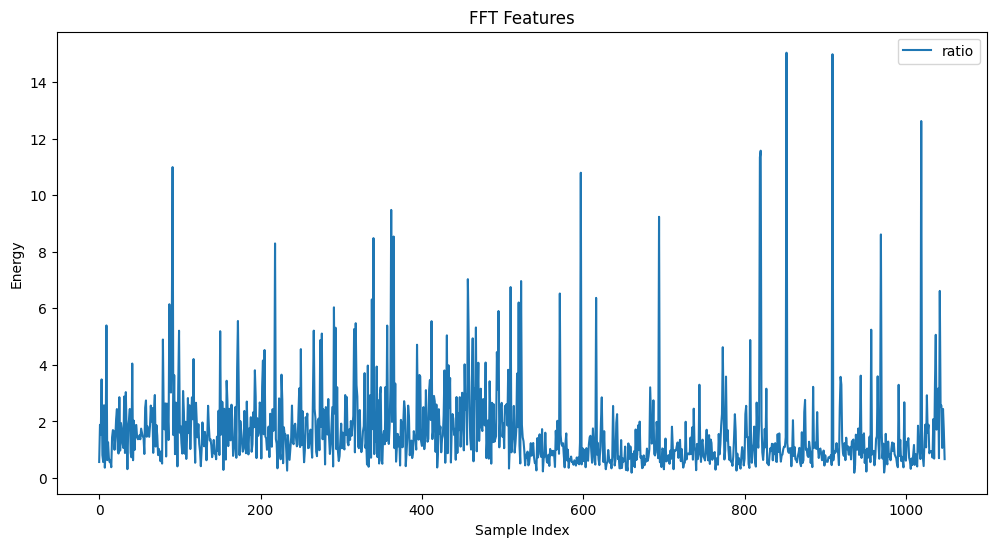

In [ ]:
import matplotlib.pyplot as plt

# Plot FFT features
plt.figure(figsize=(12, 6))
#plt.plot(df.index, df['E_alpha'], label='Alpha Energy')
#plt.plot(df.index, df['E_beta'], label='Beta Energy')
###plt.plot(df.index, df['E_theta'], label='theta Energy')
#plt.plot(df.index, df['E_delta'], label='delta Energy')

plt.plot(df.index, df['alpha_beta_ratio'], label='ratio')

plt.xlabel('Sample Index')
plt.ylabel('Energy')
plt.title('FFT Features')
plt.legend()
plt.show()

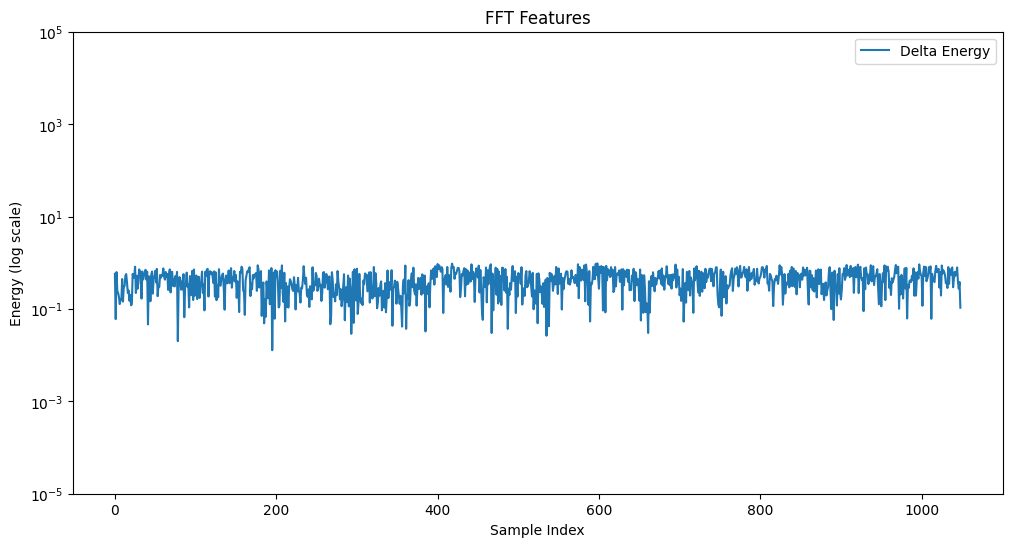

In [ ]:
import matplotlib.pyplot as plt

# Plot FFT features
plt.figure(figsize=(12, 6))
#plt.plot(df.index, df['E_alpha'], label='Alpha Energy')
#plt.plot(df.index, df['E_beta'], label='Beta Energy')
#plt.plot(df.index, df['E_theta'], label='Theta Energy')
plt.plot(df.index, df['E_delta'], label='Delta Energy')
#plt.plot(df.index, df['alpha_beta_ratio'], label='Alpha/Beta Ratio')

plt.yscale('log')

threshold = 1e5
plt.ylim([1e-5, threshold])

plt.xlabel('Sample Index')
plt.ylabel('Energy (log scale)')
plt.title('FFT Features')
plt.legend()
plt.show()


In [ ]:
X_train, X_test, y_train, y_test = train_test_split(df_scaled.drop('label', axis=1), df_scaled['label'], test_size=0.2, random_state=42)

#clf = RandomForestClassifier(n_estimators=100, random_state=42)
clf = SVC(probability=True, random_state=42)


clf.fit(X_train, y_train)

y_pred = clf.predict(X_test)

accuracy = accuracy_score(y_test, y_pred)
print(f"Classification Accuracy: {accuracy}")

Classification Accuracy: 0.7761904761904762


In [ ]:
import numpy as np
from sklearn.model_selection import GridSearchCV, train_test_split
from sklearn.svm import SVC
from sklearn.preprocessing import StandardScaler

X = df_scaled.drop('label', axis=1)
y = df_scaled['label']

# Splitting the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print("=" * 70)
print("SVM HYPERPARAMETER OPTIMIZATION")
print("=" * 70)
print(f"Training samples: {len(X_train)}")
print(f"Test samples: {len(X_test)}")
print(f"Feature count: {X_train.shape[1]}")

# Comprehensive hyperparameter grid for SVM (similar to reference project)
param_grid = {
    'C': [0.1, 1, 5, 10, 50, 100, 200],
    'gamma': ['scale', 'auto', 0.001, 0.01, 0.1, 1],
    'kernel': ['rbf', 'linear', 'poly'],
    'degree': [2, 3, 4]  # Only used for poly kernel
}

svc = SVC(probability=True, random_state=42)

print("\nStarting Grid Search with 5-fold CV...")
print(f"Total combinations to test: {7 * 6 * 3}")

grid_search = GridSearchCV(
    estimator=svc, 
    param_grid=param_grid, 
    cv=5, 
    verbose=2, 
    n_jobs=-1,
    scoring='accuracy'
)

grid_search.fit(X_train, y_train)

print("\n" + "=" * 70)
print("RESULTS")
print("=" * 70)
print(f"Best parameters: {grid_search.best_params_}")
print(f"Best cross-validation score: {grid_search.best_score_:.4f}")

model = grid_search.best_estimator_
y_pred = model.predict(X_test)
test_accuracy = model.score(X_test, y_test)

print(f"Test set accuracy: {test_accuracy:.4f}")
print("=" * 70)

# Show top 10 parameter combinations
print("\nTop 10 parameter combinations:")
results_df = pd.DataFrame(grid_search.cv_results_)
top_results = results_df.nlargest(10, 'mean_test_score')[['params', 'mean_test_score', 'std_test_score']]
for idx, row in top_results.iterrows():
    print(f"  {row['mean_test_score']:.4f} (±{row['std_test_score']:.4f}) - {row['params']}")

In [ ]:
# Feature Analysis - Understanding what drives the classification
print("=" * 70)
print("FEATURE ANALYSIS")
print("=" * 70)

# Compare feature distributions by class
print("\nFeature Means by Class:")
print("-" * 70)
feature_comparison = df.groupby('label')[columns].mean()
feature_comparison.index = ['Relax (0)', 'Concentrate (1)']
print(feature_comparison.T)

print("\n" + "=" * 70)
print("FEATURE DISCRIMINATIVE POWER (t-test p-values)")
print("=" * 70)
from scipy import stats

p_values = []
for col in columns:
    relax_vals = df[df['label'] == 0][col]
    focus_vals = df[df['label'] == 1][col]
    t_stat, p_val = stats.ttest_ind(relax_vals, focus_vals)
    p_values.append((col, p_val, abs(t_stat)))

# Sort by p-value (smaller = more discriminative)
p_values.sort(key=lambda x: x[1])

print("\nMost discriminative features (p < 0.05 = significant):")
for feat, pval, tstat in p_values[:10]:
    significance = "***" if pval < 0.001 else "**" if pval < 0.01 else "*" if pval < 0.05 else ""
    print(f"  {feat:25s} p={pval:.6f} {significance}")

print("\n" + "=" * 70)

In [ ]:
import pickle

model_filename = 'model.pkl'

with open(model_filename, 'wb') as file:
    pickle.dump(model, file)


In [ ]:
import pickle

scaler_filename = 'scaler.pkl'

with open(scaler_filename, 'wb') as file:
    pickle.dump(scaler, file)


In [ ]:
probabilities = model.predict_proba(X_test)[:,1]
print(f"Class Probabilities: {probabilities}")

Class Probabilities: [0.20789849 0.60690961 0.51871181 0.5        0.18169638 0.61336337
 0.14852363 0.66424304 0.38125568 0.68390432 0.75882422 0.59739183
 0.09336781 0.1039661  0.75855258 0.48171131 0.9391162  0.00286612
 0.7507996  0.7588946  0.24714419 0.74655254 0.69195391 0.22811566
 0.32875447 0.32773243 0.74502464 0.56701531 0.02582009 0.23134276
 0.69116098 0.79515508 0.31684018 0.86697424 0.30162363 0.75673402
 0.69754816 0.29192195 0.74313998 0.6077047  0.72577635 0.57444386
 0.52850098 0.40628377 0.78639479 0.19703447 0.27838411 0.00330522
 0.93196834 0.70777909 0.7081813  0.54786742 0.72431951 0.80436545
 0.30458124 0.79894793 0.5        0.15476544 0.96931741 0.5177313
 0.60027088 0.18267709 0.7100482  0.62662863 0.73431775 0.13987103
 0.28320897 0.92791888 0.29589109 0.60322576 0.85997865 0.82253568
 0.69569466 0.05117227 0.21471429 0.01043341 0.8575422  0.28470782
 0.75429576 0.16768192 0.15439568 0.74123609 0.73132413 0.00380875
 0.83190299 0.35213338 0.77466207 0.459343

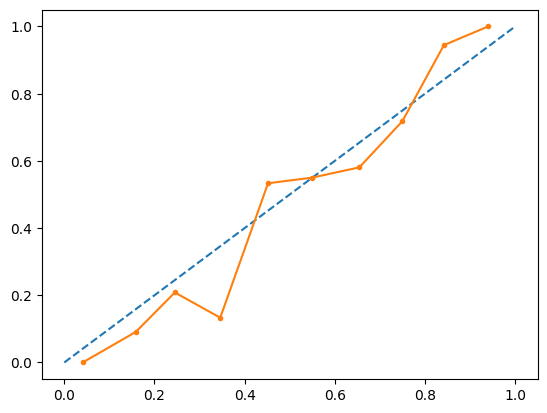

In [ ]:
from sklearn.calibration import calibration_curve
fop, mpv = calibration_curve(y_test, probabilities, n_bins=10)
plt.plot([0, 1], [0, 1], linestyle='--')
plt.plot(mpv, fop, marker='.')
plt.show()

In [ ]:
from sklearn.calibration import CalibratedClassifierCV

calibrator = CalibratedClassifierCV(model, cv=3)
calibrator.fit(X_train,y_train)
yhat = calibrator.predict(X_test)

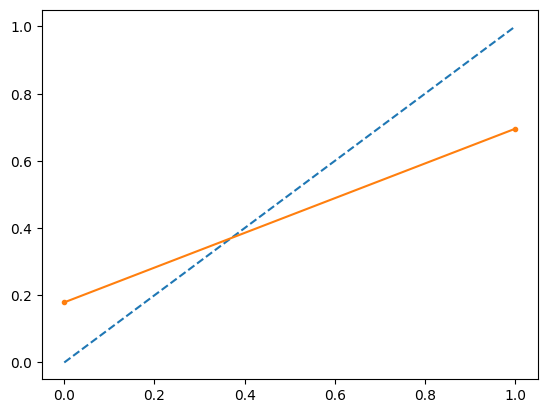

In [ ]:
fop, mpv = calibration_curve(y_test, yhat, n_bins=10)
plt.plot([0, 1], [0, 1], linestyle='--')
plt.plot(mpv, fop, marker='.')
plt.show()

In [ ]:
accuracy = accuracy_score(y_test, yhat)
print(f"Classification Accuracy: {accuracy}")

Classification Accuracy: 0.7523809523809524


In [ ]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, classification_report

y_true = df_scaled['label']
y_pred = model.predict(X_scaled)

# Accuracy
accuracy = accuracy_score(y_true, y_pred)
print(f'Accuracy: {accuracy:.4f}')

# Precision
precision = precision_score(y_true, y_pred)
print(f'Precision: {precision:.4f}')

# Recall
recall = recall_score(y_true, y_pred)
print(f'Recall: {recall:.4f}')

# F1 Score
f1 = f1_score(y_true, y_pred)
print(f'F1 Score: {f1:.4f}')

# Confusion Matrix
conf_matrix = confusion_matrix(y_true, y_pred)
print('Confusion Matrix:')
print(conf_matrix)

# Classification Report
class_report = classification_report(y_true, y_pred)
print('Classification Report:')
print(class_report)

Accuracy: 0.7388
Precision: 0.6992
Recall: 0.8356
F1 Score: 0.7613
Confusion Matrix:
[[338 188]
 [ 86 437]]
Classification Report:
              precision    recall  f1-score   support

           0       0.80      0.64      0.71       526
           1       0.70      0.84      0.76       523

    accuracy                           0.74      1049
   macro avg       0.75      0.74      0.74      1049
weighted avg       0.75      0.74      0.74      1049



/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but SVC was fitted with feature names
  warnings.warn(
